In [35]:
import numpy as np
import pandas as pd
from numpy import log2
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [36]:
df = pd.read_csv(path)

In [37]:
# Data Preparation
missing_values = df.isnull().sum()
df = df.dropna() 

features = df.drop(columns=['target']) 
target = df['target']

In [38]:
# EDA
descriptive_stats = df.describe()

print("Dataset information:")
print(f"Dataset shape: {df.shape}")
print(f"Features shape: {features.shape}")
print(f"Target shape: {target.shape}")

print("\nMissing values:")
print(missing_values)

print("\nDescriptive statistics:")
print(descriptive_stats)

print("\nTarget distribution:")
print(target.value_counts())

Dataset information:
Dataset shape: (303, 14)
Features shape: (303, 13)
Target shape: (303,)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Descriptive statistics:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     

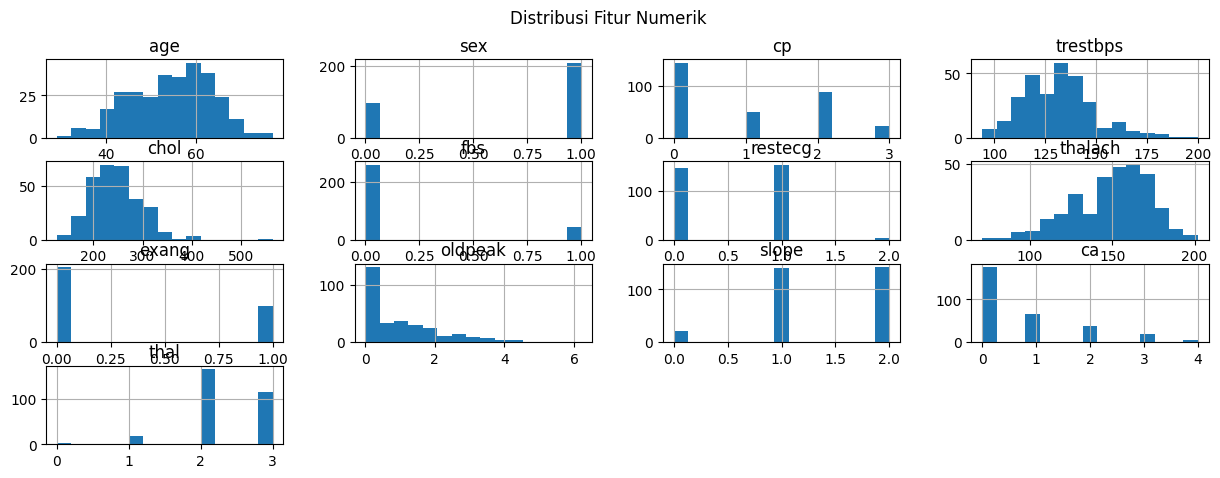

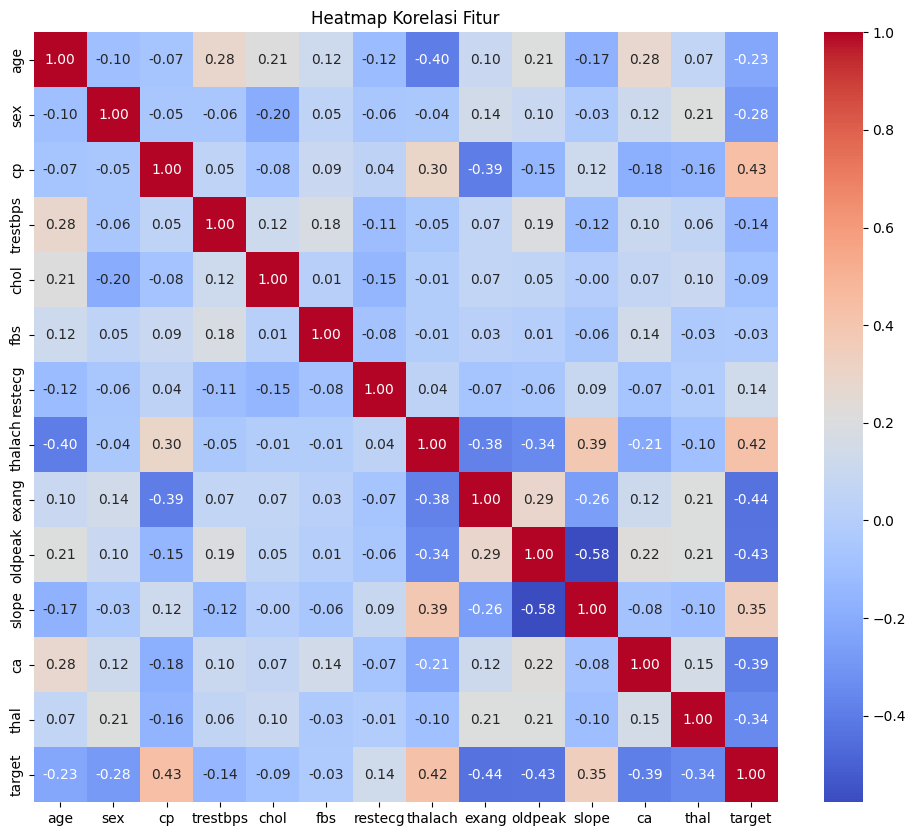

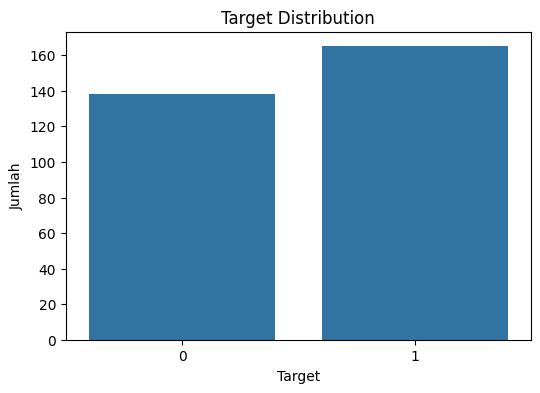

In [39]:
# Visualization
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()

if 'target' in numerical_features:
    numerical_features.remove('target')

df[numerical_features].hist(bins=15, figsize=(15, 5))
plt.suptitle('Distribusi Fitur Numerik')
plt.show()

plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Fitur')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x=target)
plt.title('Target Distribution')
plt.xlabel('Target')
plt.ylabel('Jumlah')
plt.show()

In [40]:
def entropy(df):
    total = len(df)
    counter = Counter(df)
    entrophy = 0

    for count in counter.values():
        p = count / total
        entrophy -= p * log2(p)

    return entrophy

In [41]:
# Data Classification
np.random.seed(42)
indices = np.arange(len(df))
np.random.shuffle(indices)
train_size = int(0.8 * len(df))
train_indices = indices[:train_size]
test_indices = indices[train_size:]
X_train = features.iloc[train_indices]
y_train = target.iloc[train_indices]
X_test = features.iloc[test_indices]
y_test = target.iloc[test_indices]

In [42]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [43]:
def find_best_split(X, y):
    best_gain = 0
    best_feature = None
    best_threshold = None
    current_entropy = entropy(y)
    for feature in X.columns:
        thresholds = sorted(X[feature].unique())
        for threshold in thresholds:
            left_y = y[X[feature] <= threshold]
            right_y = y[X[feature] > threshold]
            if len(left_y) == 0 or len(right_y) == 0:
                continue
            gain = current_entropy - (len(left_y) / len(y)) * entropy(left_y) - (len(right_y) / len(y)) * entropy(right_y)
            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold
    return best_feature, best_threshold

In [44]:
def build_tree(X, y, depth=0, max_depth=5):
    if len(np.unique(y)) == 1:
        return Node(value=y.iloc[0])
    if depth >= max_depth or X.shape[1] == 0:
        return Node(value=y.mode()[0])
    best_feature, best_threshold = find_best_split(X, y)
    if best_feature is None:
        return Node(value=y.mode()[0])
    left_indices = X[best_feature] <= best_threshold
    right_indices = X[best_feature] > best_threshold
    left = build_tree(X[left_indices], y[left_indices], depth + 1, max_depth)
    right = build_tree(X[right_indices], y[right_indices], depth + 1, max_depth)
    return Node(feature=best_feature, threshold=best_threshold, left=left, right=right)

tree_root = build_tree(X_train, y_train, max_depth=5)

def print_tree(node, depth=0):
    indent = '  ' * depth
    if node.value is not None:
        print(f'{indent}Leaf: {node.value}')
        return
    print(f'{indent}Feature {node.feature} <= {node.threshold}')
    print_tree(node.left, depth + 1)
    print(f'{indent}Feature {node.feature} > {node.threshold}')
    print_tree(node.right, depth + 1)

print("\nDecision Tree Structure:")
print_tree(tree_root)


Decision Tree Structure:
Feature cp <= 0
  Feature ca <= 0
    Feature thal <= 2
      Feature trestbps <= 115
        Leaf: 1
      Feature trestbps > 115
        Feature trestbps <= 136
          Leaf: 0
        Feature trestbps > 136
          Leaf: 1
    Feature thal > 2
      Feature oldpeak <= 0.4
        Feature age <= 40
          Leaf: 0
        Feature age > 40
          Leaf: 1
      Feature oldpeak > 0.4
        Leaf: 0
  Feature ca > 0
    Feature oldpeak <= 0.3
      Feature sex <= 0
        Leaf: 1
      Feature sex > 0
        Feature thalach <= 147
          Leaf: 0
        Feature thalach > 147
          Leaf: 0
    Feature oldpeak > 0.3
      Feature chol <= 299
        Leaf: 0
      Feature chol > 299
        Feature chol <= 303
          Leaf: 1
        Feature chol > 303
          Leaf: 0
Feature cp > 0
  Feature sex <= 0
    Feature ca <= 0
      Leaf: 1
    Feature ca > 0
      Feature thalach <= 97
        Leaf: 0
      Feature thalach > 97
        Feature cho

Accuracy: 0.8361
Precision: 0.8377
Recall: 0.8341
F1-Score: 0.8359


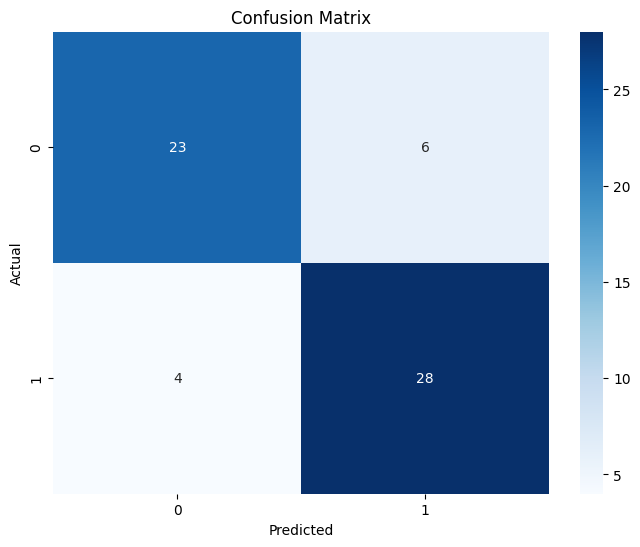

Model performance is satisfactory.
Feature cp <= 0
  Feature ca <= 0
    Feature thal <= 2
      Feature trestbps <= 115
        Leaf: 1
      Feature trestbps > 115
        Feature trestbps <= 136
          Leaf: 0
        Feature trestbps > 136
          Leaf: 1
    Feature thal > 2
      Feature oldpeak <= 0.4
        Feature age <= 40
          Leaf: 0
        Feature age > 40
          Leaf: 1
      Feature oldpeak > 0.4
        Leaf: 0
  Feature ca > 0
    Feature oldpeak <= 0.3
      Feature sex <= 0
        Leaf: 1
      Feature sex > 0
        Feature thalach <= 147
          Leaf: 0
        Feature thalach > 147
          Leaf: 0
    Feature oldpeak > 0.3
      Feature chol <= 299
        Leaf: 0
      Feature chol > 299
        Feature chol <= 303
          Leaf: 1
        Feature chol > 303
          Leaf: 0
Feature cp > 0
  Feature sex <= 0
    Feature ca <= 0
      Leaf: 1
    Feature ca > 0
      Feature thalach <= 97
        Leaf: 0
      Feature thalach > 97
        Fe

In [45]:
# Model Evaluation
def predict(tree, X):
    predictions = []
    for _, row in X.iterrows():
        node = tree
        while node.value is None:
            if row[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        predictions.append(node.value)
    return np.array(predictions)

def compute_confusion_matrix(y_true, y_pred):
    classes = np.unique(np.concatenate((y_true, y_pred)))
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    class_to_index = {cls: i for i, cls in enumerate(classes)}
    for true, pred in zip(y_true, y_pred):
        cm[class_to_index[true], class_to_index[pred]] += 1
    return cm, classes

def accuracy(cm):
    return np.trace(cm) / np.sum(cm)

def precision(cm):
    precisions = []
    for i in range(len(cm)):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        if tp + fp == 0:
            precisions.append(0)
        else:
            precisions.append(tp / (tp + fp))
    return np.mean(precisions)

def recall(cm):
    recalls = []
    for i in range(len(cm)):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        if tp + fn == 0:
            recalls.append(0)
        else:
            recalls.append(tp / (tp + fn))
    return np.mean(recalls)

def f1_score(cm):
    p = precision(cm)
    r = recall(cm)
    if p + r == 0:
        return 0
    return 2 * p * r / (p + r)

def evaluate_model(tree, X_test, y_test):
    y_pred = predict(tree, X_test)
    cm, classes = compute_confusion_matrix(y_test, y_pred)
    acc = accuracy(cm)
    prec = precision(cm)
    rec = recall(cm)
    f1 = f1_score(cm)
    return cm, classes, acc, prec, rec, f1

def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def adjust_model_if_needed(tree, X_train, y_train, X_test, y_test, current_max_depth=5):
    cm, classes, acc, prec, rec, f1 = evaluate_model(tree, X_test, y_test)
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    plot_confusion_matrix(cm, classes)
    
    if acc < 0.8:
        print("Accuracy is low, retraining with increased max_depth...")
        new_max_depth = current_max_depth + 2
        new_tree = build_tree(X_train, y_train, max_depth=new_max_depth)
        print(f"Retrained with max_depth={new_max_depth}")
        return new_tree
    else:
        print("Model performance is satisfactory.")
        return tree

tree_root = adjust_model_if_needed(tree_root, X_train, y_train, X_test, y_test)
print_tree(tree_root)